# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [132]:
pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 45.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


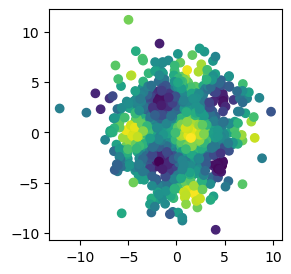

Iteration 0, Loss: 0.9741900563240051
Iteration 100, Loss: 0.8998880982398987
Iteration 200, Loss: 0.8119053840637207
Iteration 300, Loss: 0.6751894950866699
Iteration 400, Loss: 0.5361811518669128
Iteration 500, Loss: 0.4357990622520447
Iteration 600, Loss: 0.366545706987381
Iteration 700, Loss: 0.3050917387008667
Iteration 800, Loss: 0.2512214779853821
Iteration 900, Loss: 0.2176627814769745


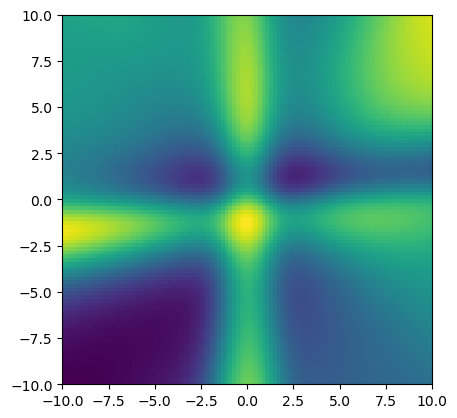

In [133]:
# Your code here
# Import necessary modules
import torch
import data
import matplotlib.pyplot as plt


# Display the data
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

# Build our model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Construct a training loop
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [134]:
# Your comment here 

# AI = Programs and algorithms that mimic human intelligence or behavior.
# Machine Learning = Systems that learn and improve from experience with data.
# Deep Learning = A type of machine learning using multi-layered neural networks.

What is a neural network?

In [135]:
# Your comment here

# Neural network is an algorithm that mimics the neural system of organisms. 
# Consists of connected decision making nodes that undergo a continuous processing of information.
# Each connected nodes have different 'weights', which means they have different importance.
# IT uses this weightage nodes to find a pattern of a given data: includes images, speech, or even makes predictions.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [136]:
# Your comment here

# The numbers mean the layers of inpiut and output. 
# 2 means there are 2 layers of input, and 50 means there are 50 layers of output.
# Thus, the above command torch.nn.Linear(2, 50) means to transform the 2D data into 50D (!) data.

What does the activation function do?

In [137]:
# Your comment here

# Activation functions are introduced to determine whether the pattern is linear or not.
# Once activation function is given, it turns on the neurons to recognize more complex pattern.

What is a loss function? Why do we need one?

In [138]:
# Your comment here

# Loss function is used to measure how well does the prediction made my a model matches with the actual data given.
# This is required because otherwise the model would not have the reference to improve the predictions.

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [139]:
# Your comment here

# It is for resetting the gradients form the previous iterations made.
# If old gradients are not cleared, it would be keep accumulating.
# Thus, it would give an incorrect gradient for the model to refer to, leading to deviation in the prediction.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [140]:
# Your code here

# Before: torch.nn.Linear(2, 50) / torch.nn.Linear(50, 1)
# After: torch.nn.Linear(2, 30) / torch.nn.Linear(30, 1)

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

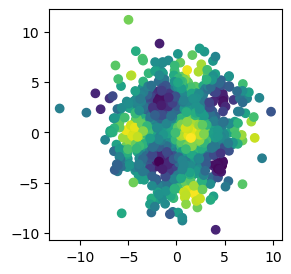

Iteration 0, Loss: 1.3142948150634766
Iteration 100, Loss: 0.9400734901428223
Iteration 200, Loss: 0.9122215509414673
Iteration 300, Loss: 0.872480034828186
Iteration 400, Loss: 0.8211103677749634
Iteration 500, Loss: 0.7572250962257385
Iteration 600, Loss: 0.6832104921340942
Iteration 700, Loss: 0.6061822175979614
Iteration 800, Loss: 0.5339096784591675
Iteration 900, Loss: 0.47167909145355225


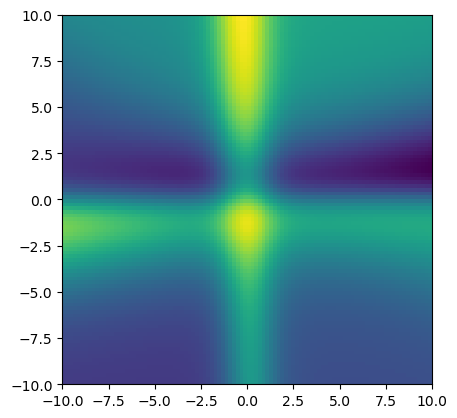

Final loss: 0.4222797155380249


In [141]:
# Your comment here

# Display the data
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

# Build our model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Construct a training loop
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

print(f'Final loss: {loss.item()}') ## Added this line to compare final loss with after parts

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

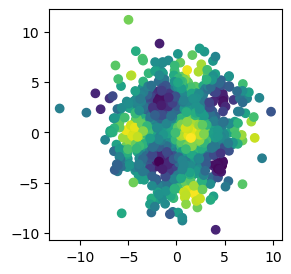

Iteration 0, Loss: 1.2852740287780762
Iteration 100, Loss: 0.8319737911224365
Iteration 200, Loss: 0.662749171257019
Iteration 300, Loss: 0.5294668674468994
Iteration 400, Loss: 0.45964229106903076
Iteration 500, Loss: 0.40400809049606323
Iteration 600, Loss: 0.3476511836051941
Iteration 700, Loss: 0.30014005303382874
Iteration 800, Loss: 0.2618882656097412
Iteration 900, Loss: 0.23356328904628754


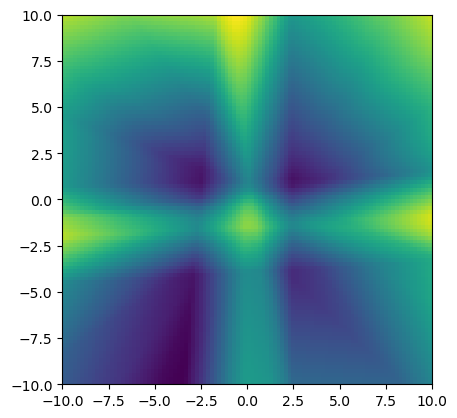

Final loss: 0.21352499723434448


In [142]:
# Your comment here

# Display the data
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

# Build our model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Construct a training loop
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

print(f'Final loss: {loss.item()}')

My answer: 
As we changed to `torch.nn.ReLU()` the overall loss (and also the final loss function) goes down, which means this model provides more accurate prediction on the actual data.

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

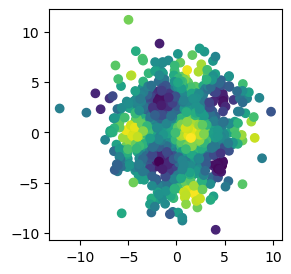

Iteration 0, Loss: 1.0656776428222656
Iteration 100, Loss: 0.7462942600250244
Iteration 200, Loss: 0.5035052299499512
Iteration 300, Loss: 0.3505514860153198
Iteration 400, Loss: 0.267606645822525
Iteration 500, Loss: 0.21571038663387299
Iteration 600, Loss: 0.18459241092205048
Iteration 700, Loss: 0.1642000675201416
Iteration 800, Loss: 0.14971238374710083
Iteration 900, Loss: 0.13787199556827545


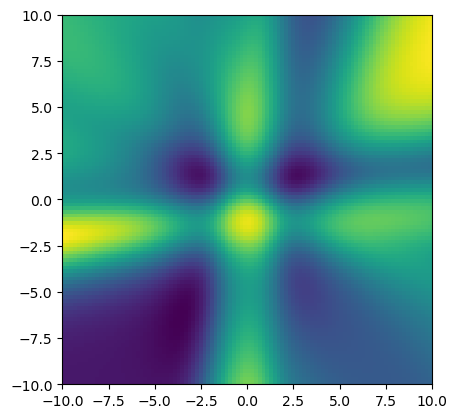

Final loss: 0.12749409675598145


In [143]:
# Your comment here

# Display the data
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

# Build our model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Construct a training loop
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

print(f'Final loss: {loss.item()}')

My answer: As we changed to torch.nn.Tanh() the overall loss (and also the final loss function) goes even more down, which means this model provides more accurate prediction on the actual data, and thus much better activation function.

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [144]:
# Your comment here 

# Sigmoid is a rational exponential function that good for probabilistic predictions as its range vary from 0 to 1. 
# However, its gradient approaches 0 as input gets larger. This could delay the learning process. 
# Also, the function is not zero-centered, which means the weight updates are not balanced.

# ReLU is an efficient activation function that returns the value itself for positive input, and 0 for any negative input (and 0).
# This is good for maintaining gradients for almost all positive values, preventing gradient loss unlike Sigmoid and Tanh.
# However, if there are too many negative inputs i.e. many zeros as output, it could completely stop learning.

# Tanh is a hyperbolic trigonometric function that can also be expressed in terms of exponents.
# It is a zero-centered function unlike Sigmoid, thus useful when it is important to balance weights.
# However, also like Sigmoid it has a vanishing-gradient problem that becomes a problem when values are large. (-ve and +ve)

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

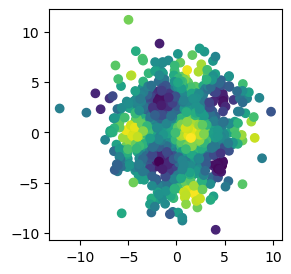

Iteration 0, Loss: 1.4960840940475464
Iteration 100, Loss: 0.5185378193855286
Iteration 200, Loss: 0.2982008457183838
Iteration 300, Loss: 0.21296006441116333
Iteration 400, Loss: 0.16416926681995392
Iteration 500, Loss: 0.13097360730171204
Iteration 600, Loss: 0.10667409747838974
Iteration 700, Loss: 0.09211954474449158
Iteration 800, Loss: 0.0834265798330307
Iteration 900, Loss: 0.07571366429328918


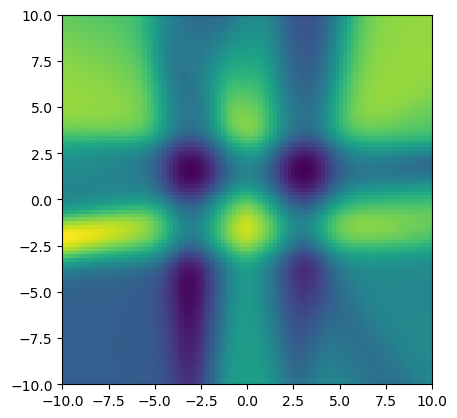

Final loss: 0.06952538341283798


In [145]:
# Your comment here

# Display the data
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

# Build our model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# Construct a training loop
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

print(f'Final loss: {loss.item()}') ## Added for loss comparison

My answer: Again, the final value of loss is much more reduced than any other activation functions. 
This means we could also change learning rate directly instead of changing a type of an activation function to reduce a final loss.
This makes sense because change of learning rate from 1e-3 to 1e-2 means it is ten times better, and thus efficient.

Modify your model to have **two hidden layers** instead of one. Give that code here.

In [146]:
# Your code here
# Follow the structure from lecture
# # e.g. one layer of 2D->30D, and another layer of 30D->50D
# model = torch.nn.Sequential(
#     torch.nn.Linear(2, 30),
#     torch.nn.Sigmoid(), ## Activation function after each layer, otherwise no complex learning possible
#     torch.nn.Linear(30, 50),
#     torch.nn.Sigmoid(), ## Activation function after each layer, otherwise no complex learning possible
#     torch.nn.Linear(50, 1)
# )

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [147]:
# Your code here
import new_data

Define a new model and train it **poorly** in the cell below.

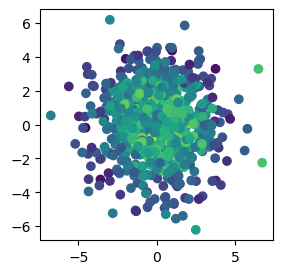

Iteration 0, Loss: 1.2310014963150024
Iteration 100, Loss: 1.0685049295425415
Iteration 200, Loss: 0.9734704494476318
Iteration 300, Loss: 0.9078709483146667
Iteration 400, Loss: 0.857876181602478
Iteration 500, Loss: 0.8162098526954651
Iteration 600, Loss: 0.7793858051300049
Iteration 700, Loss: 0.7458809614181519
Iteration 800, Loss: 0.7150371074676514
Iteration 900, Loss: 0.6865305304527283


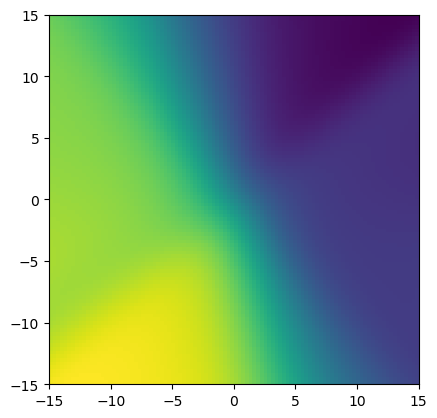

Final loss: 0.6604148745536804


In [148]:
# Your code here
import torch
import new_data

# Construct the figure
plt.figure(figsize=(3,3))
plt.scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
plt.show()

# Build our model
model_poor = torch.nn.Sequential(
    torch.nn.Linear(2, 30),  # Will use only 30D -> less dimension means less network to work
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # Slow down the learning process

# Construct a training loop
for t in range(1000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-15, 15, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output_poor = model_poor(grid).detach()
plt.imshow(output_poor, extent=(-15, 15, -15, 15))
plt.show()

print(f'Final loss: {loss.item()}')

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Iteration 0, Loss: 0.22926069796085358
Iteration 100, Loss: 0.2262393981218338
Iteration 200, Loss: 0.22608080506324768
Iteration 300, Loss: 0.22587905824184418
Iteration 400, Loss: 0.2256438136100769
Iteration 500, Loss: 0.22538165748119354
Iteration 600, Loss: 0.22509750723838806
Iteration 700, Loss: 0.2247951626777649
Iteration 800, Loss: 0.2244778424501419
Iteration 900, Loss: 0.22414788603782654
Iteration 1000, Loss: 0.22380520403385162
Iteration 1100, Loss: 0.22343376278877258
Iteration 1200, Loss: 0.22301986813545227
Iteration 1300, Loss: 0.22262288630008698
Iteration 1400, Loss: 0.22223171591758728
Iteration 1500, Loss: 0.22183580696582794
Iteration 1600, Loss: 0.221429705619812
Iteration 1700, Loss: 0.22102360427379608
Iteration 1800, Loss: 0.2206132858991623
Iteration 1900, Loss: 0.22032934427261353


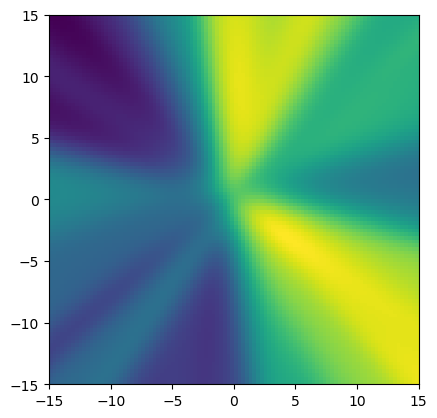

Final loss: 0.21972261369228363


In [152]:
# Build our model
model_well = torch.nn.Sequential(
    torch.nn.Linear(2, 30), 
    torch.nn.Tanh(),
    torch.nn.Linear(30, 30),
    torch.nn.Tanh(), # Change to Tanh()
    torch.nn.Linear(30, 1)
)

# Train our model
# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2) # Speed up the learning process

# Construct a training loop
for t in range(2000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Evaluate our model
new_x = torch.linspace(-15, 15, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output_well = model_well(grid).detach()
plt.imshow(output_well, extent=(-15, 15, -15, 15))
plt.show()

print(f'Final loss: {loss.item()}')

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

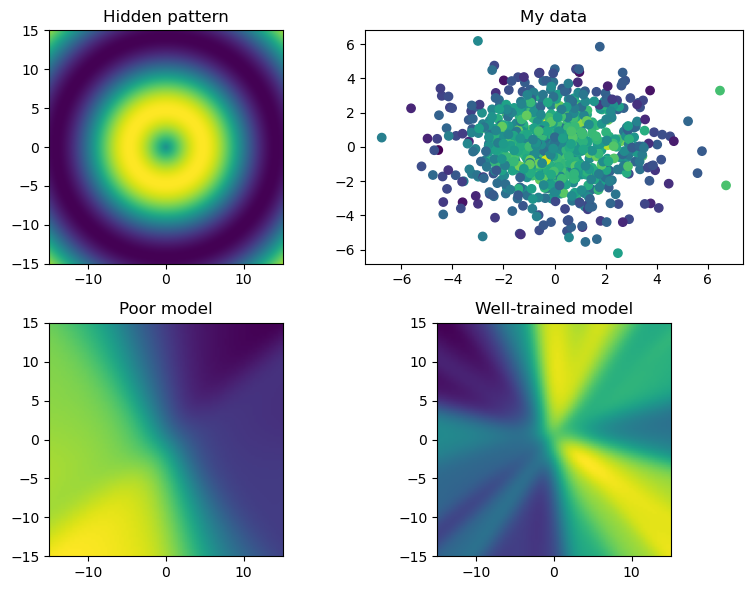

In [153]:
# Your code here

import matplotlib.pyplot as plt
import numpy as np

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# First subplot: Hidden pattern
axes[0, 0].imshow(new_data.pattern, extent=(-15, 15, -15, 15))
axes[0, 0].set_title("Hidden pattern")

# Second subplot: My data
axes[0, 1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
axes[0, 1].set_title("My data")

# Third subplot: model_poor
axes[1, 0].imshow(output_poor, extent=(-15, 15, -15, 15))
axes[1, 0].set_title("Poor model")

# Fourth subplot
axes[1, 1].imshow(output_well, extent=(-15, 15, -15, 15))
axes[1, 1].set_title("Well-trained model")

# Adjust layout
plt.tight_layout()
plt.show()


# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [ ]:
# Your code here

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!